In [ ]:
import torch, os
print("CUDA available:", torch.cuda.is_available())
print("Torch version:", torch.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

if device == "cuda":
    !nvidia-smi

CUDA available: True
Torch version: 2.10.0+cu128
device: cuda
Sun Mar  1 08:16:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             48W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |          

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os
assert os.path.exists("/content/drive/MyDrive"), "Drive mount olmadı!"
print("✅ Drive mounted.")

Mounted at /content/drive
✅ Drive mounted.


In [ ]:
from pathlib import Path
import os


DRIVE_BASE = "/content/drive/MyDrive/Retino-Project/Data"
TRAIN_ZIP  = f"{DRIVE_BASE}/train.zip"
LABEL_CSV  = f"{DRIVE_BASE}/trainLabels.csv"
# ============================================

# Colab local proje dizini (runtime reset olursa silinir -> normal)
PROJECT_DIR = "/content/Retino-Project"
DATA_DIR    = f"{PROJECT_DIR}/data"
UNZIP_DIR   = f"{DATA_DIR}/train_unzipped"

# Drive output dizini (kalıcı)
RUN_NAME = "run_001"  # her yeni denemede artır: run_002...
OUT_BASE_DRIVE = "/content/drive/MyDrive/Retino-Project/Model/"
RUN_DIR_DRIVE  = f"{OUT_BASE_DRIVE}/{RUN_NAME}"

CKPT_DRIVE = f"{RUN_DIR_DRIVE}/checkpoints"
LOG_DRIVE  = f"{RUN_DIR_DRIVE}/logs"
ART_DRIVE  = f"{RUN_DIR_DRIVE}/artifacts"

# Local output (hızlı yaz) -> sonra drive'a kopyalayacağız
RUN_DIR_LOCAL = "/content/run_local"
CKPT_LOCAL = f"{RUN_DIR_LOCAL}/checkpoints"
LOG_LOCAL  = f"{RUN_DIR_LOCAL}/logs"
ART_LOCAL  = f"{RUN_DIR_LOCAL}/artifacts"

# klasörleri oluştur
for p in [DATA_DIR, UNZIP_DIR, CKPT_DRIVE, LOG_DRIVE, ART_DRIVE, CKPT_LOCAL, LOG_LOCAL, ART_LOCAL]:
    Path(p).mkdir(parents=True, exist_ok=True)

print("TRAIN_ZIP:", TRAIN_ZIP)
print("LABEL_CSV:", LABEL_CSV)
print("UNZIP_DIR:", UNZIP_DIR)
print("RUN_DIR_DRIVE:", RUN_DIR_DRIVE)

assert os.path.exists(TRAIN_ZIP), "❌ TRAIN_ZIP yolu yanlış ya da dosya yok."
assert os.path.exists(LABEL_CSV), "❌ LABEL_CSV yolu yanlış ya da dosya yok."
print("✅ Paths OK.")

TRAIN_ZIP: /content/drive/MyDrive/Retino-Project/Data/train.zip
LABEL_CSV: /content/drive/MyDrive/Retino-Project/Data/trainLabels.csv
UNZIP_DIR: /content/Retino-Project/data/train_unzipped
RUN_DIR_DRIVE: /content/drive/MyDrive/Retino-Project/Model//run_001
✅ Paths OK.


In [ ]:
import shutil, os

def safe_copy_to_drive(src_path, drive_path):
    assert os.path.exists("/content/drive/MyDrive"), "Drive mount yok!"
    tmp_path = drive_path + ".tmp"
    shutil.copy2(src_path, tmp_path)
    os.replace(tmp_path, drive_path)

In [ ]:
import os, subprocess, shutil

local_zip = f"{DATA_DIR}/train.zip"

# daha önce kopyalanmışsa tekrar kopyalama
if not os.path.exists(local_zip):
    print("📦 Copy zip from Drive -> /content ...")
    shutil.copy2(TRAIN_ZIP, local_zip)
else:
    print("✅ local zip already exists:", local_zip)

# unzip kontrol
sample_file_check = os.path.join(UNZIP_DIR, "10_left.jpeg")
if os.path.exists(sample_file_check):
    print("✅ Already unzipped.")
else:
    print("🧩 Unzipping...")
    subprocess.run(["bash","-lc", f"unzip -q '{local_zip}' -d '{UNZIP_DIR}'"], check=True)
    print("✅ Unzip done.")



📦 Copy zip from Drive -> /content ...
🧩 Unzipping...
✅ Unzip done.


In [ ]:
# ======================================================
# HÜCRE 5 — CSV oku + kolon düzelt + doğru klasör ayarla
# ======================================================

import pandas as pd
import os
import glob

# CSV
df = pd.read_csv(LABEL_CSV)
print(df.head())
print("Columns:", df.columns.tolist(), "| rows:", len(df))

# Kolon normalize
rename_map = {}
if "image" in df.columns: rename_map["image"] = "image_id"
if "id_code" in df.columns: rename_map["id_code"] = "image_id"
if "level" in df.columns: rename_map["level"] = "label"
if "diagnosis" in df.columns: rename_map["diagnosis"] = "label"
df = df.rename(columns=rename_map)

assert "image_id" in df.columns
assert "label" in df.columns

df["label"] = df["label"].astype(int)
df["image_id"] = df["image_id"].astype(str)

# 🔴 KRİTİK DÜZELTME
IMG_DIR = os.path.join(UNZIP_DIR, "train")
print("Using image folder:", IMG_DIR)

# Uzantı tespit
ext_counts = {
    ".jpeg": len(glob.glob(os.path.join(IMG_DIR, "*.jpeg"))),
    ".jpg":  len(glob.glob(os.path.join(IMG_DIR, "*.jpg"))),
    ".png":  len(glob.glob(os.path.join(IMG_DIR, "*.png"))),
}
best_ext = max(ext_counts, key=ext_counts.get)
print("Detected ext counts:", ext_counts, "-> chosen:", best_ext)

def ensure_ext(x):
    if x.lower().endswith((".jpg",".jpeg",".png")):
        return x
    return x + best_ext

df["image_id"] = df["image_id"].apply(ensure_ext)

# Missing kontrol
missing = 0
for i in range(min(500, len(df))):
    if not os.path.exists(os.path.join(IMG_DIR, df.loc[i, "image_id"])):
        missing += 1

print("Missing in first 500:", missing)
assert missing < 50, "❌ Çok missing var. Hâlâ path yanlış."

print("✅ CSV-image mapping OK.")

      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1
Columns: ['image', 'level'] | rows: 35126
Using image folder: /content/Retino-Project/data/train_unzipped/train
Detected ext counts: {'.jpeg': 35126, '.jpg': 0, '.png': 0} -> chosen: .jpeg
Missing in first 500: 0
✅ CSV-image mapping OK.


In [ ]:
from sklearn.model_selection import train_test_split
import json

SEED = 42
VAL_RATIO = 0.2

train_df, val_df = train_test_split(
    df,
    test_size=VAL_RATIO,
    random_state=SEED,
    stratify=df["label"]
)

print("Train:", len(train_df), "Val:", len(val_df))
print("Train label counts:\n", train_df["label"].value_counts().sort_index())
print("Val label counts:\n", val_df["label"].value_counts().sort_index())

split_info = {
    "seed": SEED,
    "val_ratio": VAL_RATIO,
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "train_label_counts": train_df["label"].value_counts().sort_index().to_dict(),
    "val_label_counts": val_df["label"].value_counts().sort_index().to_dict(),
}

split_local = f"{ART_LOCAL}/split_info.json"
split_drive = f"{ART_DRIVE}/split_info.json"
with open(split_local, "w", encoding="utf-8") as f:
    json.dump(split_info, f, ensure_ascii=False, indent=2)
safe_copy_to_drive(split_local, split_drive)
print("✅ Saved split_info to Drive:", split_drive)

Train: 28100 Val: 7026
Train label counts:
 label
0    20648
1     1954
2     4234
3      698
4      566
Name: count, dtype: int64
Val label counts:
 label
0    5162
1     489
2    1058
3     175
4     142
Name: count, dtype: int64
✅ Saved split_info to Drive: /content/drive/MyDrive/Retino-Project/Model//run_001/artifacts/split_info.json


In [ ]:
!pip -q install timm

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm

from sklearn.metrics import confusion_matrix, cohen_kappa_score, accuracy_score, balanced_accuracy_score, f1_score
import timm

In [ ]:
IMG_DIR = os.path.join(UNZIP_DIR, "train")
print("IMG_DIR:", IMG_DIR)
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class RetinopathyDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.img_dir, row["image_id"])
        img = Image.open(path).convert("RGB")
        y = int(row["label"])
        if self.transform:
            img = self.transform(img)
        return img, y

train_ds = RetinopathyDataset(train_df, IMG_DIR, transform=train_transform)
val_ds   = RetinopathyDataset(val_df,   IMG_DIR, transform=val_transform)

print("✅ datasets ready:", len(train_ds), len(val_ds))

IMG_DIR: /content/Retino-Project/data/train_unzipped/train
✅ datasets ready: 28100 7026


In [ ]:
# 1) WeightedRandomSampler (önerilen)
counts = train_df["label"].value_counts().sort_index()
class_counts = counts.values
class_weights = 1.0 / class_counts
sample_weights = train_df["label"].map({i: class_weights[i] for i in range(len(class_weights))}).values

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

print("Train counts:", counts.to_dict())
print("Class weights (inverse):", class_weights)

# 2) Opsiyonel class-weight loss (istersen)
use_class_weight_loss = False   # True yaparsan loss weighted olur
cw = class_weights / class_weights.sum() * len(class_weights)  # normalize
cw_tensor = torch.tensor(cw, dtype=torch.float32).to(device)
print("use_class_weight_loss:", use_class_weight_loss)
print("cw_tensor:", cw_tensor)

Train counts: {0: 20648, 1: 1954, 2: 4234, 3: 698, 4: 566}
Class weights (inverse): [4.84308408e-05 5.11770727e-04 2.36183278e-04 1.43266476e-03
 1.76678445e-03]
use_class_weight_loss: False
cw_tensor: tensor([0.0606, 0.6404, 0.2955, 1.7927, 2.2108], device='cuda:0')


In [ ]:
NUM_WORKERS = 8

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False
)

print("✅ loaders ready. workers:", NUM_WORKERS)

✅ loaders ready. workers: 8


In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    y_true_all, y_pred_all = [], []

    for x, y in tqdm(loader, desc="Validating", leave=False, dynamic_ncols=True):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)

        preds = logits.argmax(dim=1)
        y_true_all.append(y.detach().cpu().numpy())
        y_pred_all.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)
    cm = confusion_matrix(y_true, y_pred)

    return {
        "val_loss": total_loss / len(loader.dataset),
        "acc": accuracy_score(y_true, y_pred),
        "bal_acc": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "cm": cm.tolist(),
    }

In [ ]:
import json, time

def train_model(model_name, epochs=30, lr=1e-4, weight_decay=1e-4, patience=7):
    best_local = f"{CKPT_LOCAL}/best_{model_name}.pt"
    last_local = f"{CKPT_LOCAL}/last_{model_name}.pt"
    log_local  = f"{LOG_LOCAL}/log_{model_name}.jsonl"

    best_drive = f"{CKPT_DRIVE}/best_{model_name}.pt"
    last_drive = f"{CKPT_DRIVE}/last_{model_name}.pt"
    log_drive  = f"{LOG_DRIVE}/log_{model_name}.jsonl"

    # config kaydet (1 kere)
    config = {
        "model": model_name,
        "epochs": epochs,
        "lr": lr,
        "weight_decay": weight_decay,
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "val_ratio": VAL_RATIO,
        "sampler": True,
        "use_class_weight_loss": use_class_weight_loss
    }
    cfg_local = f"{ART_LOCAL}/config_{model_name}.json"
    cfg_drive = f"{ART_DRIVE}/config_{model_name}.json"
    with open(cfg_local, "w", encoding="utf-8") as f:
        json.dump(config, f, ensure_ascii=False, indent=2)
    safe_copy_to_drive(cfg_local, cfg_drive)

    # model
    model = timm.create_model(model_name, pretrained=True, num_classes=5).to(device)

    # loss
    if use_class_weight_loss:
        criterion = nn.CrossEntropyLoss(weight=cw_tensor)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda") if device == "cuda" else None

    best_qwk = -1e9
    bad = 0

    print("\n========================")
    print("MODEL:", model_name)
    print("epochs:", epochs, "| lr:", lr, "| img:", IMG_SIZE, "| batch:", BATCH_SIZE)
    print("Drive run:", RUN_DIR_DRIVE)
    print("========================\n")

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        model.train()
        total = 0.0

        pbar = tqdm(train_loader, desc=f"{model_name} | Epoch {epoch}/{epochs}", dynamic_ncols=True)
        for x, y in pbar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            if device == "cuda":
                with torch.amp.autocast("cuda"):
                    logits = model(x)
                    loss = criterion(logits, y)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(x)
                loss = criterion(logits, y)
                loss.backward()
                optimizer.step()

            total += loss.item() * x.size(0)
            pbar.set_postfix(loss=float(loss.item()))

        scheduler.step()
        train_loss = total / len(train_loader.dataset)

        m = evaluate(model, val_loader, criterion)
        metrics = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "lr": float(optimizer.param_groups[0]["lr"]),
            "model": model_name,
            "img_size": IMG_SIZE,
            "batch_size": BATCH_SIZE,
            "epoch_minutes": round((time.time()-t0)/60, 2),
            **{k: (float(v) if not isinstance(v, list) else v) for k,v in m.items()}
        }
        print(metrics)

        # log local -> drive
        with open(log_local, "a", encoding="utf-8") as f:
            f.write(json.dumps(metrics) + "\n")
        safe_copy_to_drive(log_local, log_drive)

        # last local -> drive (HER EPOCH)
        torch.save({"state_dict": model.state_dict(), "epoch": epoch, "metrics": metrics}, last_local)
        safe_copy_to_drive(last_local, last_drive)

        # best
        if metrics["qwk"] > best_qwk:
            best_qwk = metrics["qwk"]
            bad = 0
            torch.save({"state_dict": model.state_dict(), "epoch": epoch, "best_qwk": best_qwk, "metrics": metrics}, best_local)
            safe_copy_to_drive(best_local, best_drive)
            print(f"✅ BEST UPDATED: qwk={best_qwk:.4f} -> {best_drive}")
        else:
            bad += 1
            if bad >= patience:
                print(f"⏹️ Early stopping ({patience})")
                break

    return best_drive, best_qwk

In [ ]:
best_swin_path, best_swin_qwk = train_model(
    "swin_tiny_patch4_window7_224",
    epochs=20,
    lr=1e-4,
    patience=7
)
print("✅ Swin best:", best_swin_qwk, best_swin_path)


MODEL: swin_tiny_patch4_window7_224
epochs: 20 | lr: 0.0001 | img: 224 | batch: 32
Drive run: /content/drive/MyDrive/Retino-Project/Model//run_001



swin_tiny_patch4_window7_224 | Epoch 1/20:   0%|          | 0/879 [00:00<?, ?it/s]

Validating:   0%|          | 0/220 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.0582076213877396, 'lr': 9.938441702975689e-05, 'model': 'swin_tiny_patch4_window7_224', 'img_size': 224, 'batch_size': 32, 'epoch_minutes': 11.58, 'val_loss': 0.821646016512099, 'acc': 0.7524907486478793, 'bal_acc': 0.5172756301485115, 'macro_f1': 0.45669076853456636, 'weighted_f1': 0.734850756010596, 'qwk': 0.6453095429307439, 'cm': [[4686, 173, 224, 15, 64], [398, 47, 40, 2, 2], [431, 39, 364, 113, 111], [18, 1, 39, 75, 42], [2, 0, 9, 16, 115]]}
✅ BEST UPDATED: qwk=0.6453 -> /content/drive/MyDrive/Retino-Project/Model//run_001/checkpoints/best_swin_tiny_patch4_window7_224.pt


Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20>
Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20>Exception ignored in: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20>Traceback (most recent call last):

self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        
self._shutdown_workers()Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

  

...

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20><function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20>
Exception ignored in: 
Exception ignored in: Exception ignored in: Exception ignored in: Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20><function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20>Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20><function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20>
    

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20>sel

{'epoch': 7, 'train_loss': 0.41764577385369567, 'lr': 7.269952498697734e-05, 'model': 'swin_tiny_patch4_window7_224', 'img_size': 224, 'batch_size': 32, 'epoch_minutes': 12.04, 'val_loss': 1.0514530852042538, 'acc': 0.6001992598918303, 'bal_acc': 0.534322388908101, 'macro_f1': 0.5190165165897078, 'weighted_f1': 0.6628665535715736, 'qwk': 0.6304265109895371, 'cm': [[3300, 1691, 158, 3, 10], [206, 253, 29, 0, 1], [241, 247, 503, 48, 19], [10, 8, 77, 71, 9], [4, 2, 36, 10, 90]]}


swin_tiny_patch4_window7_224 | Epoch 8/20:   0%|          | 0/879 [00:00<?, ?it/s]

Validating:   0%|          | 0/220 [00:00<?, ?it/s]

{'epoch': 8, 'train_loss': 0.3633166727985776, 'lr': 6.545084971874738e-05, 'model': 'swin_tiny_patch4_window7_224', 'img_size': 224, 'batch_size': 32, 'epoch_minutes': 11.93, 'val_loss': 1.0649018582034036, 'acc': 0.5844007970395674, 'bal_acc': 0.5361214099092304, 'macro_f1': 0.4922417727611534, 'weighted_f1': 0.640092563729891, 'qwk': 0.5785453485104196, 'cm': [[3094, 1424, 627, 6, 11], [169, 224, 95, 0, 1], [169, 170, 630, 55, 34], [6, 6, 85, 64, 14], [2, 0, 38, 8, 94]]}
⏹️ Early stopping (7)
✅ Swin best: 0.6453095429307439 /content/drive/MyDrive/Retino-Project/Model//run_001/checkpoints/best_swin_tiny_patch4_window7_224.pt


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 5

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    num_classes=NUM_CLASSES
)

model.to(device)

print("Model created.")

Model created.


In [ ]:
BEST_PATH = "/content/drive/MyDrive/Retino-Project/Model/run_001/checkpoints/best_swin_tiny_patch4_window7_224.pt"

ckpt = torch.load(BEST_PATH, map_location=device)

if "model" in ckpt:
    model.load_state_dict(ckpt["model"])
elif "state_dict" in ckpt:
    model.load_state_dict(ckpt["state_dict"])
else:
    model.load_state_dict(ckpt)

model.eval()

print("Checkpoint loaded successfully.")

Checkpoint loaded successfully.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, cohen_kappa_score

y_true, y_pred = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(y.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
bal = balanced_accuracy_score(y_true, y_pred)
macro = f1_score(y_true, y_pred, average="macro")
w = f1_score(y_true, y_pred, average="weighted")
qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
cm = confusion_matrix(y_true, y_pred)

print({
    "acc": acc,
    "bal_acc": bal,
    "macro_f1": macro,
    "weighted_f1": w,
    "qwk": qwk
})

{'acc': 0.7524907486478793, 'bal_acc': np.float64(0.5172756301485115), 'macro_f1': 0.45669076853456636, 'weighted_f1': 0.734850756010596, 'qwk': np.float64(0.6453095429307439)}


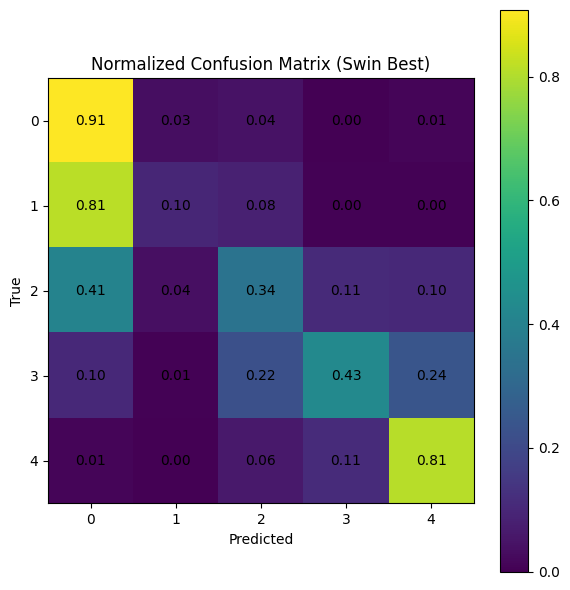

Saved: /content/drive/MyDrive/Retino-Project/Model/run_001/plots/cm_swin_best.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

SAVE_DIR = "/content/drive/MyDrive/Retino-Project/Model/run_001/plots"
os.makedirs(SAVE_DIR, exist_ok=True)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,6))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("Normalized Confusion Matrix (Swin Best)")
plt.colorbar()
ticks = np.arange(5)
plt.xticks(ticks, ticks)
plt.yticks(ticks, ticks)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(5):
    for j in range(5):
        plt.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center")

plt.tight_layout()
out_path = os.path.join(SAVE_DIR, "cm_swin_best.png")
plt.savefig(out_path, dpi=200)
plt.show()
print("Saved:", out_path)

In [ ]:
import os, glob, json
import pandas as pd

# Swin log klasörü
SWIN_LOG_DIR = "/content/drive/MyDrive/Retino-Project/Model/run_001/logs"

# log dosyasını otomatik bul
candidates = sorted(glob.glob(os.path.join(SWIN_LOG_DIR, "*.jsonl")))
print("Found logs:", candidates)

assert len(candidates) > 0, "❌ Swin için log dosyası bulunamadı!"

# En olası swin log’u seç: içinde 'swin' geçen
swin_logs = [p for p in candidates if "swin" in os.path.basename(p).lower()]
LOG_PATH = swin_logs[0] if len(swin_logs) else candidates[0]

print("✅ Using LOG_PATH:", LOG_PATH)

# oku
rows = []
with open(LOG_PATH, "r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

df_log = pd.DataFrame(rows)
print("Total epochs in log:", len(df_log))
df_log[["epoch","train_loss","val_loss","qwk","lr"]].head()

Found logs: ['/content/drive/MyDrive/Retino-Project/Model/run_001/logs/log_swin_tiny_patch4_window7_224.jsonl']
✅ Using LOG_PATH: /content/drive/MyDrive/Retino-Project/Model/run_001/logs/log_swin_tiny_patch4_window7_224.jsonl
Total epochs in log: 8


,epoch,train_loss,val_loss,qwk,lr
0,1,1.058208,0.821646,0.645310,0.000099
1,2,0.815197,1.038751,0.498218,0.000098
2,3,0.666682,0.905902,0.621594,0.000095
3,4,0.585788,1.046784,0.540883,0.000090
4,5,0.525428,0.965255,0.570691,0.000085


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1671, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

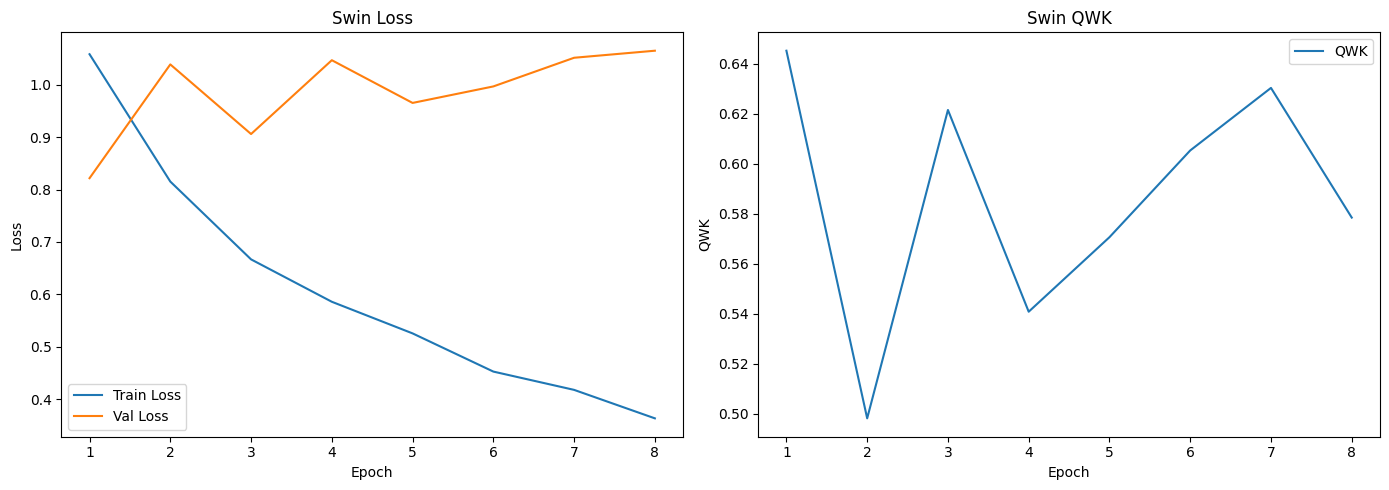

Saved: /content/drive/MyDrive/Retino-Project/Model/run_001/plots/swin_loss_qwk.png


In [ ]:
out_dir = "/content/drive/MyDrive/Retino-Project/Model/run_001/plots"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "swin_loss_qwk.png")
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(df_log["epoch"], df_log["train_loss"], label="Train Loss")
plt.plot(df_log["epoch"], df_log["val_loss"], label="Val Loss")
plt.legend(); plt.title("Swin Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.subplot(1,2,2)
plt.plot(df_log["epoch"], df_log["qwk"], label="QWK")
plt.legend(); plt.title("Swin QWK"); plt.xlabel("Epoch"); plt.ylabel("QWK")
plt.tight_layout()
plt.savefig(out_path, dpi=200)
plt.show()
print("Saved:", out_path)

# 2.Model = **efficientnet_b3**

In [ ]:
RUN_NAME = "run_002_effb3"
OUT_BASE_DRIVE = "/content/drive/MyDrive/Retino-Project/Model"
RUN_DIR_DRIVE  = f"{OUT_BASE_DRIVE}/{RUN_NAME}"

CKPT_DRIVE = f"{RUN_DIR_DRIVE}/checkpoints"
LOG_DRIVE  = f"{RUN_DIR_DRIVE}/logs"
ART_DRIVE  = f"{RUN_DIR_DRIVE}/artifacts"

RUN_DIR_LOCAL = "/content/run_local_effb3"
CKPT_LOCAL = f"{RUN_DIR_LOCAL}/checkpoints"
LOG_LOCAL  = f"{RUN_DIR_LOCAL}/logs"
ART_LOCAL  = f"{RUN_DIR_LOCAL}/artifacts"

from pathlib import Path
for p in [CKPT_DRIVE, LOG_DRIVE, ART_DRIVE, CKPT_LOCAL, LOG_LOCAL, ART_LOCAL]:
    Path(p).mkdir(parents=True, exist_ok=True)

print("✅ RUN_DIR_DRIVE:", RUN_DIR_DRIVE)

✅ RUN_DIR_DRIVE: /content/drive/MyDrive/Retino-Project/Model/run_002_effb3


In [ ]:
import numpy as np
import torch
from torch.utils.data import WeightedRandomSampler, DataLoader

counts = train_df["label"].value_counts().sort_index()
class_counts = counts.values.astype(np.float32)

# ✅ soft inverse: sqrt
class_weights = (1.0 / class_counts) ** 0.5

weight_map = {i: class_weights[i] for i in range(len(class_weights))}
sample_weights = train_df["label"].map(weight_map).values

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

print("Train counts:", counts.to_dict())
print("Class weights (sqrt inverse):", class_weights)

# DataLoader'ı sampler ile yeniden kur
NUM_WORKERS = 8
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False
)

print("✅ loaders updated with soft sampler")

Train counts: {0: 20648, 1: 1954, 2: 4234, 3: 698, 4: 566}
Class weights (sqrt inverse): [0.00695923 0.02262235 0.01536826 0.03785056 0.04203314]
✅ loaders updated with soft sampler


In [ ]:
from torchvision import transforms

IMG_SIZE = 224
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# Dataset’lere transform güncelle
train_ds.transform = train_transform
val_ds.transform   = val_transform

print("✅ transforms updated (soft)")

✅ transforms updated (soft)


In [ ]:
import os, shutil

def safe_copy_to_drive(src_path, drive_path):
    assert os.path.exists("/content/drive/MyDrive"), "Drive mount yok!"
    tmp_path = drive_path + ".tmp"
    shutil.copy2(src_path, tmp_path)
    os.replace(tmp_path, drive_path)

# **efficient-b3 modelini eğitmek**

In [ ]:
best_eff_path, best_eff_qwk = train_model(
    "efficientnet_b3",
    epochs=20,
    lr=5e-5,
    patience=7
)
print("✅ EfficientNet-B3 best:", best_eff_qwk, best_eff_path)


MODEL: efficientnet_b3
epochs: 20 | lr: 5e-05 | img: 224 | batch: 32
Drive run: /content/drive/MyDrive/Retino-Project/Model/run_002_effb3



efficientnet_b3 | Epoch 1/20:   0%|          | 0/879 [00:00<?, ?it/s]

Validating:   0%|          | 0/220 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.3642269429787197, 'lr': 4.9692208514878444e-05, 'model': 'efficientnet_b3', 'img_size': 224, 'batch_size': 32, 'epoch_minutes': 11.18, 'val_loss': 0.8978756181270079, 'acc': 0.6374893253629377, 'bal_acc': 0.41851995382759843, 'macro_f1': 0.40589052822880556, 'weighted_f1': 0.6565760578916173, 'qwk': 0.47357931800158604, 'cm': [[3913, 665, 513, 32, 39], [324, 93, 68, 2, 2], [466, 130, 346, 80, 36], [29, 8, 69, 58, 11], [18, 3, 27, 25, 69]]}
✅ BEST UPDATED: qwk=0.4736 -> /content/drive/MyDrive/Retino-Project/Model/run_002_effb3/checkpoints/best_efficientnet_b3.pt


efficientnet_b3 | Epoch 2/20:   0%|          | 0/879 [00:00<?, ?it/s]

...

{'epoch': 15, 'train_loss': 0.06733582805590273, 'lr': 7.322330470336315e-06, 'model': 'efficientnet_b3', 'img_size': 224, 'batch_size': 32, 'epoch_minutes': 12.11, 'val_loss': 1.1169218795102036, 'acc': 0.7611727867919157, 'bal_acc': 0.47314784971343915, 'macro_f1': 0.49165673634179796, 'weighted_f1': 0.7414871228731481, 'qwk': 0.6152941847510409, 'cm': [[4697, 148, 301, 9, 7], [382, 42, 64, 0, 1], [487, 25, 465, 53, 28], [23, 0, 79, 63, 10], [20, 0, 24, 17, 81]]}


efficientnet_b3 | Epoch 16/20:   0%|          | 0/879 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20>Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7c3754352a20>
if w.is_alive():
Traceback (most recent call last):

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()self._shutdown_workers() Exception ignored in: 

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/datalo

Validating:   0%|          | 0/220 [00:00<?, ?it/s]

{'epoch': 16, 'train_loss': 0.05825711223048247, 'lr': 4.774575140626317e-06, 'model': 'efficientnet_b3', 'img_size': 224, 'batch_size': 32, 'epoch_minutes': 11.47, 'val_loss': 1.127620117568644, 'acc': 0.7607458013094222, 'bal_acc': 0.47901603947327087, 'macro_f1': 0.4966051774425175, 'weighted_f1': 0.7424515605311813, 'qwk': 0.6151521168403491, 'cm': [[4687, 169, 281, 13, 12], [389, 49, 50, 1, 0], [487, 31, 462, 51, 27], [23, 1, 77, 64, 10], [16, 1, 27, 15, 83]]}
⏹️ Early stopping (7)
✅ EfficientNet-B3 best: 0.6223325468379783 /content/drive/MyDrive/Retino-Project/Model/run_002_effb3/checkpoints/best_efficientnet_b3.pt


# **Ensemble (Swin + B3)** modelleri yüklemek

In [ ]:
import torch, timm
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SWIN_CKPT = "/content/drive/MyDrive/Retino-Project/Model/run_001/checkpoints/best_swin_tiny_patch4_window7_224.pt"
B3_CKPT   = "/content/drive/MyDrive/Retino-Project/Model/run_002_effb3/checkpoints/best_efficientnet_b3.pt"

def load_ckpt(model_name, ckpt_path):
    m = timm.create_model(model_name, pretrained=False, num_classes=5).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    if "model" in ckpt:
        m.load_state_dict(ckpt["model"])
    elif "state_dict" in ckpt:
        m.load_state_dict(ckpt["state_dict"])
    else:
        m.load_state_dict(ckpt)
    m.eval()
    return m

swin = load_ckpt("swin_tiny_patch4_window7_224", SWIN_CKPT)
b3   = load_ckpt("efficientnet_b3", B3_CKPT)

print("✅ models loaded")

✅ models loaded


**# Val üzerinde probability almak**

In [ ]:
@torch.no_grad()
def predict_proba(model, loader):
    probs_all, y_all = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        probs_all.append(probs)
        y_all.append(y.numpy())
    return np.vstack(probs_all), np.concatenate(y_all)

p_swin, y_true = predict_proba(swin, val_loader)
p_b3,   _      = predict_proba(b3,   val_loader)

print("✅ probs shapes:", p_swin.shape, p_b3.shape, "labels:", y_true.shape)

✅ probs shapes: (7026, 5) (7026, 5) labels: (7026,)


In [ ]:
from sklearn.metrics import cohen_kappa_score

p_ens = 0.5*p_swin + 0.5*p_b3
y_pred = p_ens.argmax(axis=1)

qwk_ens = cohen_kappa_score(y_true, y_pred, weights="quadratic")
print("✅ Ensemble QWK (argmax):", qwk_ens)

✅ Ensemble QWK (argmax): 0.6600233778507745


In [ ]:
import numpy as np
from sklearn.metrics import cohen_kappa_score

def expected_score(probs):
    classes = np.arange(5)
    return (probs * classes).sum(axis=1)

def apply_thresholds(x, t):
    return np.digitize(x, t)

def tune_thresholds(probs, y_true, n_iter=30000, seed=42):
    rng = np.random.default_rng(seed)
    x = expected_score(probs)

    best_t = np.array([0.5, 1.5, 2.5, 3.5])
    best_q = cohen_kappa_score(y_true, apply_thresholds(x, best_t), weights="quadratic")

    for _ in range(n_iter):
        t = best_t + rng.normal(0, 0.06, size=4)
        t = np.sort(t)
        if not (0.05 < t[0] < t[1] < t[2] < t[3] < 3.95):
            continue
        q = cohen_kappa_score(y_true, apply_thresholds(x, t), weights="quadratic")
        if q > best_q:
            best_q, best_t = q, t

    return best_t, best_q

t_best, qwk_tuned = tune_thresholds(p_ens, y_true, n_iter=8000)
print("✅ Best thresholds:", t_best)
print("✅ Tuned Ensemble QWK:", qwk_tuned)

✅ Best thresholds: [0.79553588 1.40517033 2.23727684 3.36263588]
✅ Tuned Ensemble QWK: 0.7196475144079706


In [ ]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

best_w, best_q = None, -1
for w in np.linspace(0, 1, 21):   # 0,0.05,...1
    p_tmp = w*p_swin + (1-w)*p_b3
    q = cohen_kappa_score(y_true, p_tmp.argmax(axis=1), weights="quadratic")
    if q > best_q:
        best_q, best_w = q, w

print("✅ Best Swin weight:", best_w)
print("✅ Best argmax QWK:", best_q)

✅ Best Swin weight: 0.7000000000000001
✅ Best argmax QWK: 0.6808326492437928


In [ ]:
import json, os

# 🔹 checkpoint yollarını tekrar tanımla
SWIN_BEST = "/content/drive/MyDrive/Retino-Project/Model/run_001/checkpoints/best_swin_tiny_patch4_window7_224.pt"
B3_BEST   = "/content/drive/MyDrive/Retino-Project/Model/run_002_effb3/checkpoints/best_efficientnet_b3.pt"

# 🔹 klasör oluştur
SAVE_DIR = "/content/drive/MyDrive/Retino-Project/Model/ensemble"
os.makedirs(SAVE_DIR, exist_ok=True)

# 🔹 sonuç sözlüğü
out = {
    "swin_best_path": SWIN_BEST,
    "b3_best_path": B3_BEST,
    "ensemble_qwk_argmax": float(qwk_ens),
    "thresholds": t_best.tolist(),
    "ensemble_qwk_tuned": float(qwk_tuned)
}

# 🔹 json olarak kaydet
with open(f"{SAVE_DIR}/ensemble_result.json", "w") as f:
    json.dump(out, f, indent=2)

print("✅ Ensemble results saved to:", f"{SAVE_DIR}/ensemble_result.json")

✅ Ensemble results saved to: /content/drive/MyDrive/Retino-Project/Model/ensemble/ensemble_result.json


# **Joint search (Ağırlık + tuning) (compute-dostu)**

In [ ]:
import numpy as np
from sklearn.metrics import cohen_kappa_score

def expected_score(probs):
    return (probs * np.arange(5)).sum(axis=1)

def apply_thresholds(x, t):
    return np.digitize(x, t)

def tune_thresholds_seed(probs, y_true, n_iter=6000, seed=42):
    rng = np.random.default_rng(seed)
    x = expected_score(probs)

    best_t = np.array([0.5, 1.5, 2.5, 3.5])
    best_q = cohen_kappa_score(y_true, apply_thresholds(x, best_t), weights="quadratic")

    for _ in range(n_iter):
        t = best_t + rng.normal(0, 0.06, size=4)
        t = np.sort(t)
        if not (0.05 < t[0] < t[1] < t[2] < t[3] < 3.95):
            continue
        q = cohen_kappa_score(y_true, apply_thresholds(x, t), weights="quadratic")
        if q > best_q:
            best_q, best_t = q, t

    return best_t, float(best_q)

# --- joint search ---
best = {"q": -1, "w": None, "t": None, "seed": None}

weights = np.linspace(0.35, 0.75, 17)  # 0.35..0.75
seeds = [1, 7, 42, 99]                 # birkaç başlangıç

for w in weights:
    p = w*p_swin + (1-w)*p_b3
    for sd in seeds:
        t, q = tune_thresholds_seed(p, y_true, n_iter=6000, seed=sd)
        if q > best["q"]:
            best = {"q": q, "w": float(w), "t": t, "seed": sd}

print("✅ BEST (joint):")
print("  qwk:", best["q"])
print("  w_swin:", best["w"], "w_b3:", 1-best["w"])
print("  thresholds:", best["t"])
print("  seed:", best["seed"])

✅ BEST (joint):
  qwk: 0.7219158177435328
  w_swin: 0.575 w_b3: 0.42500000000000004
  thresholds: [0.78520522 1.45666584 2.31408906 2.90769264]
  seed: 1


# **Bulduğun en iyi ağırlıkta “parlatma”**

In [ ]:
w_star = best["w"]
p_star = w_star*p_swin + (1-w_star)*p_b3

t_star, q_star = tune_thresholds_seed(p_star, y_true, n_iter=30000, seed=best["seed"])
print("✅ POLISHED:")
print("  w_swin:", w_star, "w_b3:", 1-w_star)
print("  thresholds:", t_star)
print("  tuned QWK:", q_star)

✅ POLISHED:
  w_swin: 0.575 w_b3: 0.42500000000000004
  thresholds: [0.76665428 1.45864812 2.32284375 2.91847456]
  tuned QWK: 0.722051774910454


# **En iyi sonucu Drive’a kaydet (mutlaka)**

In [ ]:
import json, os

SAVE_DIR = "/content/drive/MyDrive/Retino-Project/Model/ensemble"
os.makedirs(SAVE_DIR, exist_ok=True)

out = {
    "best_qwk": float(q_star),
    "w_swin": float(w_star),
    "w_b3": float(1-w_star),
    "thresholds": t_star.tolist()
}

with open(f"{SAVE_DIR}/ensemble_best_joint.json", "w") as f:
    json.dump(out, f, indent=2)

print("✅ saved:", f"{SAVE_DIR}/ensemble_best_joint.json")

✅ saved: /content/drive/MyDrive/Retino-Project/Model/ensemble/ensemble_best_joint.json


# **train output**

In [ ]:
import os

BASE_OUT = "/content/drive/MyDrive/Retino-Project/OUTPUT"

DIR_MODEL   = os.path.join(BASE_OUT, "model_analysis")
DIR_DATA    = os.path.join(BASE_OUT, "data_analysis")
DIR_ENSEMB  = os.path.join(BASE_OUT, "ensemble")

for d in [DIR_MODEL, DIR_DATA, DIR_ENSEMB]:
    os.makedirs(d, exist_ok=True)

print("✅ OUTPUT ready at:", BASE_OUT)

✅ OUTPUT ready at: /content/drive/MyDrive/Retino-Project/OUTPUT


# **Swin & EffB3 Confusion Matrix Kaydet**

🔵 Loading Swin...


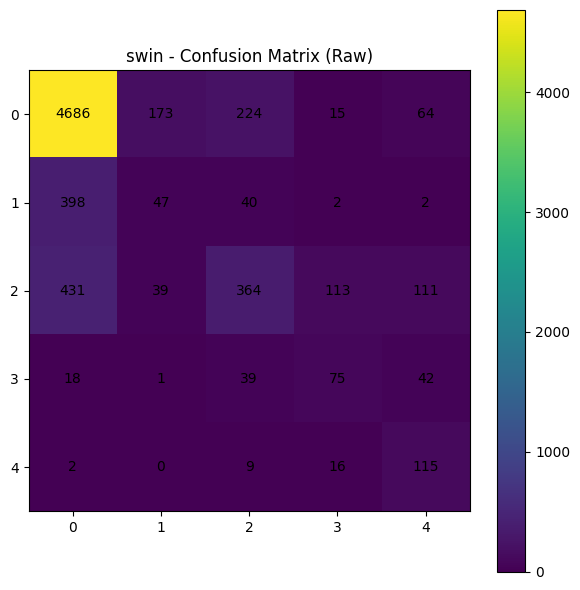

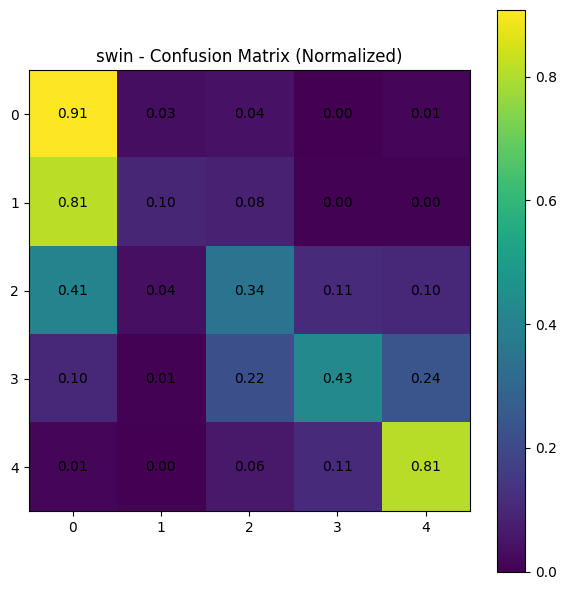

✅ Saved: /content/drive/MyDrive/Retino-Project/OUTPUT/model_analysis/swin_cm_raw.png
✅ Saved: /content/drive/MyDrive/Retino-Project/OUTPUT/model_analysis/swin_cm_norm.png
🔵 Loading EfficientNet-B3...


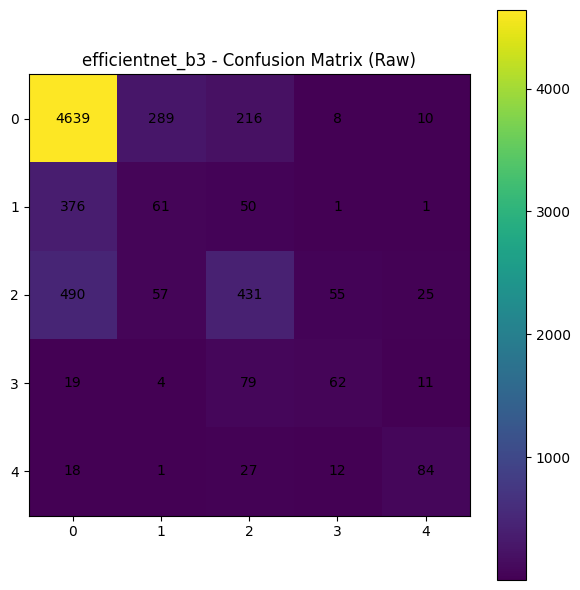

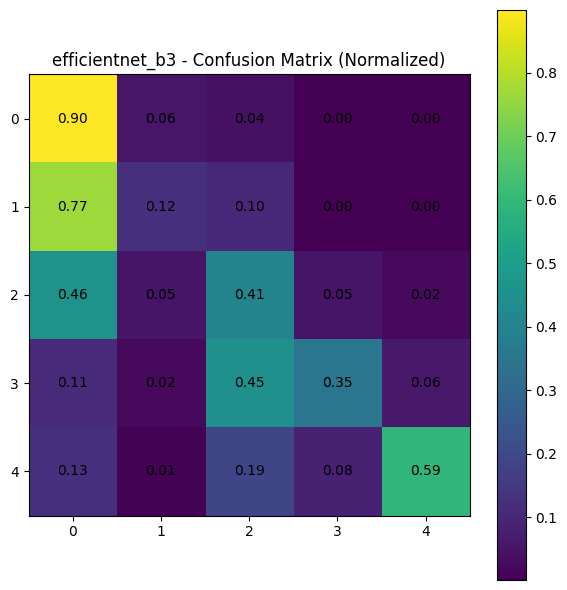

✅ Saved: /content/drive/MyDrive/Retino-Project/OUTPUT/model_analysis/efficientnet_b3_cm_raw.png
✅ Saved: /content/drive/MyDrive/Retino-Project/OUTPUT/model_analysis/efficientnet_b3_cm_norm.png
🎉 Confusion matrices saved in: /content/drive/MyDrive/Retino-Project/OUTPUT/model_analysis


In [ ]:
import torch
import timm
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==== OUTPUT klasör ====
BASE_OUT = "/content/drive/MyDrive/Retino-Project/OUTPUT/model_analysis"
os.makedirs(BASE_OUT, exist_ok=True)

# ==== Model yolları ====
SWIN_PATH = "/content/drive/MyDrive/Retino-Project/Model/run_001/checkpoints/best_swin_tiny_patch4_window7_224.pt"
B3_PATH   = "/content/drive/MyDrive/Retino-Project/Model/run_002_effb3/checkpoints/best_efficientnet_b3.pt"

# ==== Model yükleme fonksiyonu ====
def load_model(model_name, ckpt_path):
    model = timm.create_model(model_name, pretrained=False, num_classes=5)
    ckpt = torch.load(ckpt_path, map_location=device)
    if "model" in ckpt:
        model.load_state_dict(ckpt["model"])
    elif "state_dict" in ckpt:
        model.load_state_dict(ckpt["state_dict"])
    else:
        model.load_state_dict(ckpt)
    model = model.to(device)
    model.eval()
    return model

# ==== Tahmin alma ====
@torch.no_grad()
def get_predictions(model):
    y_true = []
    y_pred = []
    for x, y in val_loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred)

# ==== Confusion matrix kaydet ====
def save_confusion(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4])

    # RAW
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title(f"{name} - Confusion Matrix (Raw)")
    plt.colorbar()
    for i in range(5):
        for j in range(5):
            plt.text(j,i,str(cm[i,j]),ha="center",va="center")
    plt.tight_layout()
    raw_path = os.path.join(BASE_OUT, f"{name}_cm_raw.png")
    plt.savefig(raw_path,dpi=200)
    plt.show()

    # NORMALIZED
    cm_norm = cm.astype(float)/cm.sum(axis=1,keepdims=True)
    plt.figure(figsize=(6,6))
    plt.imshow(cm_norm)
    plt.title(f"{name} - Confusion Matrix (Normalized)")
    plt.colorbar()
    for i in range(5):
        for j in range(5):
            plt.text(j,i,f"{cm_norm[i,j]:.2f}",ha="center",va="center")
    plt.tight_layout()
    norm_path = os.path.join(BASE_OUT, f"{name}_cm_norm.png")
    plt.savefig(norm_path,dpi=200)
    plt.show()

    print("✅ Saved:", raw_path)
    print("✅ Saved:", norm_path)

# ================================
# SWIN
print("🔵 Loading Swin...")
swin_model = load_model("swin_tiny_patch4_window7_224", SWIN_PATH)
y_true_swin, y_pred_swin = get_predictions(swin_model)
save_confusion(y_true_swin, y_pred_swin, "swin")

# ================================
# EfficientNet-B3
print("🔵 Loading EfficientNet-B3...")
b3_model = load_model("efficientnet_b3", B3_PATH)
y_true_b3, y_pred_b3 = get_predictions(b3_model)
save_confusion(y_true_b3, y_pred_b3, "efficientnet_b3")

print("🎉 Confusion matrices saved in:", BASE_OUT)

# **Swin & B3 Train/Val Loss + QWK Grafikleri **

🔵 Loading Swin log...


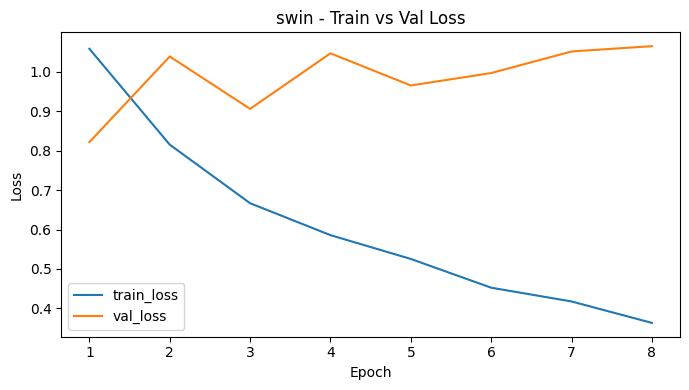

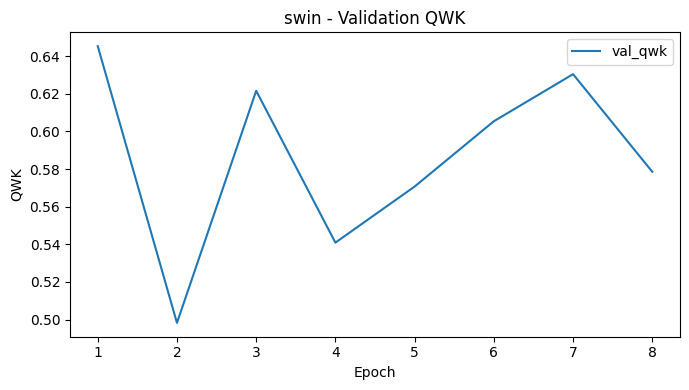

✅ Saved: /content/drive/MyDrive/Retino-Project/OUTPUT/model_analysis/swin_loss.png
✅ Saved: /content/drive/MyDrive/Retino-Project/OUTPUT/model_analysis/swin_qwk.png
🔵 Loading EfficientNet-B3 log...


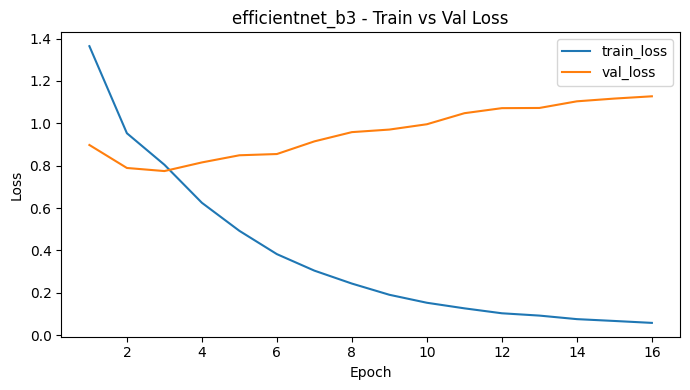

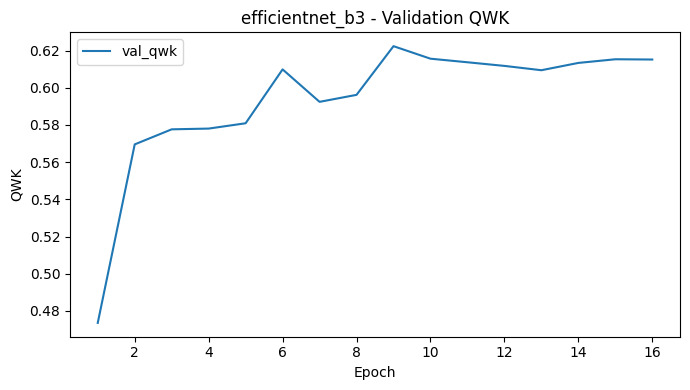

✅ Saved: /content/drive/MyDrive/Retino-Project/OUTPUT/model_analysis/efficientnet_b3_loss.png
✅ Saved: /content/drive/MyDrive/Retino-Project/OUTPUT/model_analysis/efficientnet_b3_qwk.png
🎉 Training curves saved in: /content/drive/MyDrive/Retino-Project/OUTPUT/model_analysis


In [ ]:
import os
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt

BASE_OUT = "/content/drive/MyDrive/Retino-Project/OUTPUT/model_analysis"
os.makedirs(BASE_OUT, exist_ok=True)

SWIN_LOG_DIR = "/content/drive/MyDrive/Retino-Project/Model/run_001/logs"
B3_LOG_DIR   = "/content/drive/MyDrive/Retino-Project/Model/run_002_effb3/logs"

def find_log_file(log_dir):
    files = sorted(glob.glob(os.path.join(log_dir, "*.jsonl")))
    if not files:
        raise FileNotFoundError(f"Log bulunamadı: {log_dir}")
    return files[0]

def load_log(log_path):
    rows = []
    with open(log_path, "r") as f:
        for line in f:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

def save_training_curves(df, name):
    # LOSS
    plt.figure(figsize=(7,4))
    plt.plot(df["epoch"], df["train_loss"], label="train_loss")
    plt.plot(df["epoch"], df["val_loss"], label="val_loss")
    plt.legend()
    plt.title(f"{name} - Train vs Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.tight_layout()
    p1 = os.path.join(BASE_OUT, f"{name}_loss.png")
    plt.savefig(p1, dpi=200)
    plt.show()

    # QWK
    plt.figure(figsize=(7,4))
    plt.plot(df["epoch"], df["qwk"], label="val_qwk")
    plt.legend()
    plt.title(f"{name} - Validation QWK")
    plt.xlabel("Epoch")
    plt.ylabel("QWK")
    plt.tight_layout()
    p2 = os.path.join(BASE_OUT, f"{name}_qwk.png")
    plt.savefig(p2, dpi=200)
    plt.show()

    df.to_csv(os.path.join(BASE_OUT, f"{name}_training_log.csv"), index=False)

    print("✅ Saved:", p1)
    print("✅ Saved:", p2)

# ==== SWIN ====
print("🔵 Loading Swin log...")
swin_log_path = find_log_file(SWIN_LOG_DIR)
df_swin = load_log(swin_log_path)
save_training_curves(df_swin, "swin")

# ==== EfficientNet-B3 ====
print("🔵 Loading EfficientNet-B3 log...")
b3_log_path = find_log_file(B3_LOG_DIR)
df_b3 = load_log(b3_log_path)
save_training_curves(df_b3, "efficientnet_b3")

print("🎉 Training curves saved in:", BASE_OUT)

# **Train & Val Class Distribution**

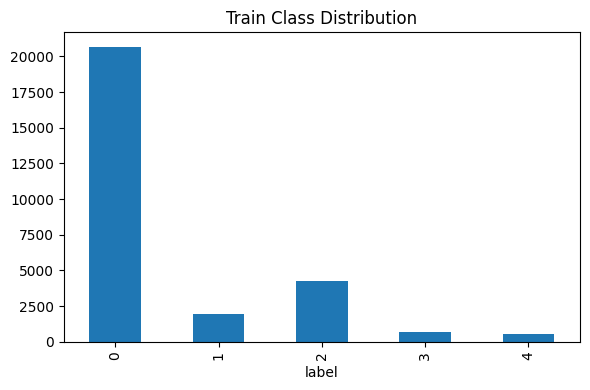

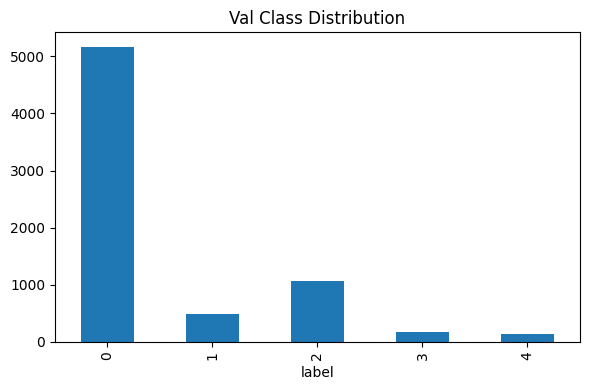

✅ Saved class distribution plots


In [ ]:
import matplotlib.pyplot as plt

# Train
plt.figure(figsize=(6,4))
train_df["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Train Class Distribution")
plt.tight_layout()
p1=os.path.join(DIR_DATA,"train_class_distribution.png")
plt.savefig(p1,dpi=200)
plt.show()

# Val
plt.figure(figsize=(6,4))
val_df["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Val Class Distribution")
plt.tight_layout()
p2=os.path.join(DIR_DATA,"val_class_distribution.png")
plt.savefig(p2,dpi=200)
plt.show()

print("✅ Saved class distribution plots")

# Ensemble Confusion Matrix (FINAL)

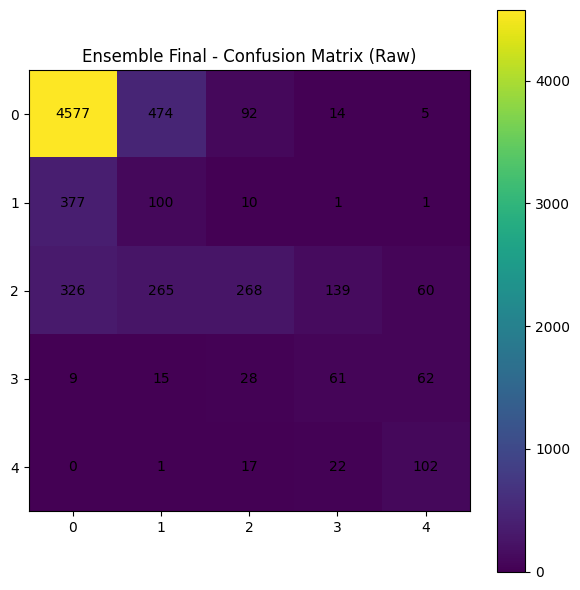

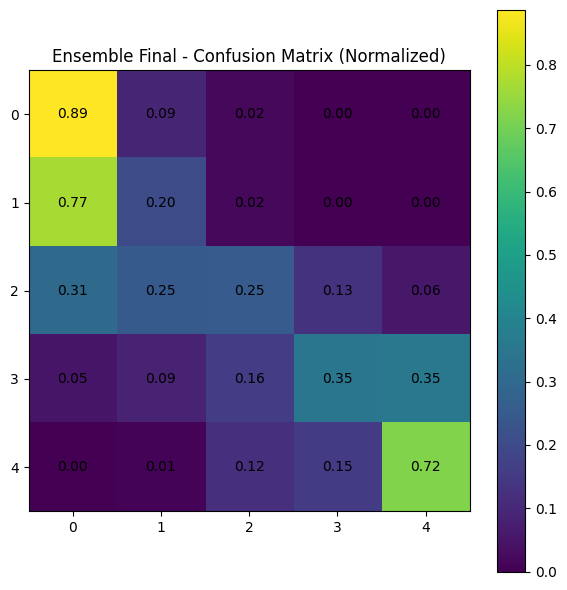

✅ Saved: /content/drive/MyDrive/Retino-Project/OUTPUT/ensemble/ensemble_final_cm_raw.png
✅ Saved: /content/drive/MyDrive/Retino-Project/OUTPUT/ensemble/ensemble_final_cm_norm.png


In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

DIR_ENSEMB = "/content/drive/MyDrive/Retino-Project/OUTPUT/ensemble"
os.makedirs(DIR_ENSEMB, exist_ok=True)

# Final ayarların
w_swin = 0.575
w_b3   = 0.425
thresholds = np.array([0.76665428, 1.45864812, 2.32284375, 2.91847456])

# Ensemble probability
p_ens = w_swin*p_swin + w_b3*p_b3

# Expected score
x_val = (p_ens * np.arange(5)).sum(axis=1)

# Threshold uygulama
y_ens = np.digitize(x_val, thresholds)

# Confusion matrix
cm = confusion_matrix(y_true, y_ens, labels=[0,1,2,3,4])

# RAW
plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("Ensemble Final - Confusion Matrix (Raw)")
plt.colorbar()
for i in range(5):
    for j in range(5):
        plt.text(j,i,str(cm[i,j]),ha="center",va="center")
plt.tight_layout()
raw_path = os.path.join(DIR_ENSEMB,"ensemble_final_cm_raw.png")
plt.savefig(raw_path,dpi=200)
plt.show()

# NORMALIZED
cm_norm = cm.astype(float)/cm.sum(axis=1,keepdims=True)

plt.figure(figsize=(6,6))
plt.imshow(cm_norm)
plt.title("Ensemble Final - Confusion Matrix (Normalized)")
plt.colorbar()
for i in range(5):
    for j in range(5):
        plt.text(j,i,f"{cm_norm[i,j]:.2f}",ha="center",va="center")
plt.tight_layout()
norm_path = os.path.join(DIR_ENSEMB,"ensemble_final_cm_norm.png")
plt.savefig(norm_path,dpi=200)
plt.show()

print("✅ Saved:", raw_path)
print("✅ Saved:", norm_path)

# **Final Ensemble Config JSON**

In [ ]:
import json

final_summary = {
    "swin_best_qwk": 0.6453,
    "effb3_best_qwk": 0.6223,
    "ensemble_argmax_qwk": 0.6600,
    "ensemble_tuned_qwk": 0.722051774910454,
    "w_swin": 0.575,
    "w_b3": 0.425,
    "thresholds": thresholds.tolist()
}

json_path = os.path.join(DIR_ENSEMB,"final_ensemble_summary.json")

with open(json_path,"w") as f:
    json.dump(final_summary,f,indent=2)

print("✅ Saved:",json_path)

✅ Saved: /content/drive/MyDrive/Retino-Project/OUTPUT/ensemble/final_ensemble_summary.json


# **Augmentation Örnek Görselleri **

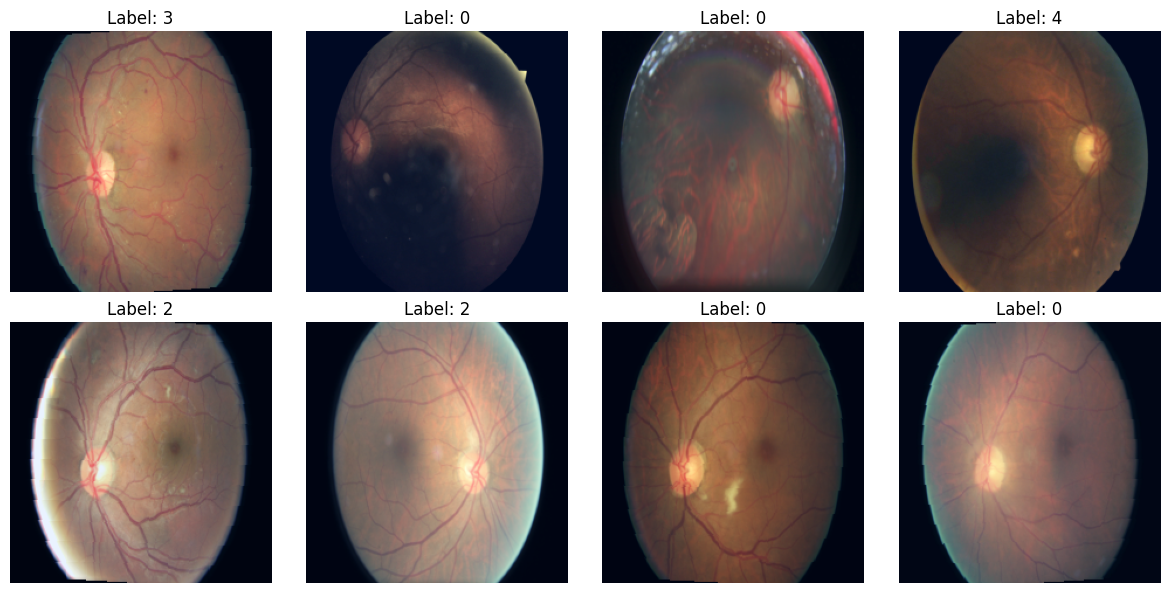

✅ Saved augmentation examples


In [ ]:
import matplotlib.pyplot as plt

sample_batch = next(iter(train_loader))
images, labels = sample_batch

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    img = images[i].permute(1,2,0).numpy()
    plt.imshow((img-img.min())/(img.max()-img.min()))
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

aug_path=os.path.join(DIR_DATA,"augmentation_examples.png")
plt.tight_layout()
plt.savefig(aug_path,dpi=200)
plt.show()

print("✅ Saved augmentation examples")